In [6]:
# 표준 라이브러리
from pathlib import Path
import platform
from typing import List, Sequence, Any
import sys
import os

# 서드 파티 라이브러리
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.colors import Colormap
import seaborn as sns

## 통계 모듈
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 로컬 모듈
sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / 'src'))
from src.plot import plot_box, plot_hist, plot_stacked_bar, plot_heatmap, plot_prop_bar, plot_mean_sem, plot_scatter_jitter
from src.utils import cramers_v, interpret_cramers_v, check_expected_frequencies, standardized_residuals
from src.utils import check_normality, check_homogeneity, calculate_eta_squared, calculate_epsilon_squared, perform_dunn_test, perform_gameshowell, perform_tukey_hsd
from src.utils import generate_colormap

DATA_DIR = Path('../data/processed')

In [7]:
system = platform.system()

if system == 'Windows':
    # Windows: 맑은 고딕 사용
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif system == 'Darwin':  # Darwin = macOS
    # macOS: 애플 고딕 사용
    plt.rcParams['font.family'] = 'AppleGothic'
    
elif system == 'Linux':
    # Linux: 나눔 고딕 사용 (사전 설치 필요)
    # 터미널: sudo apt-get install -y fonts-nanum
    plt.rcParams['font.family'] = 'Freesentation'
    plt.rcParams['font.weight'] = 600  # SemiBold에 해당
    
else:
    print(f"알 수 없는 OS: {system}")

# 모든 OS 공통: 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"OS: {system}, 설정된 폰트: {plt.rcParams['font.family']}")

OS: Linux, 설정된 폰트: ['Freesentation']


In [8]:
pandas_kwargs = {
    'parse_dates': ['purchase_time', 'approved_time', 'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time'],
    'date_format': '%Y-%m-%d %H:%M:%S',
    'memory_map': True
}

processed_data = pd.read_csv(DATA_DIR / 'processed_data.csv', **pandas_kwargs)
processed_data

,order_id,order_qty,total_price,product_id,product_qty,category,review_score,price,freight_value,purchase_time,...,city_cust,state_cust,customer_id,customer_unique_id,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell
0,00e7ee1b050b8499577073aeb2a297a1,1,146.87,a9516a079e37a9c9c36b9b78b10169e8,1,가구·인테리어,4.0,124.99,21.88,2017-05-16 15:05:35,...,franca,SP,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
1,29150127e6685892b6eab3eec79f59c7,1,335.48,4aa6014eceb682077f9dc4bffebc05b0,1,생활용품,5.0,289.00,46.48,2018-01-12 20:48:24,...,sao bernardo do campo,SP,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,b8bc237ba3788b23da09c0f1f3a3288c,88303,itajai,SC,-26.920912,-48.684937
2,b2059ed67ce144a36e2aa97d2c9e9ad2,1,157.73,bd07b66896d6f1494f5b86251848ced7,1,가구·인테리어,5.0,139.94,17.79,2018-05-19 16:07:45,...,sao paulo,SP,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
3,951670f92359f4fe4a63112aa7306eba,1,173.30,a5647c44af977b148e0a3a4751a09e2e,1,가구·인테리어,5.0,149.94,23.36,2018-03-13 16:06:38,...,mogi das cruzes,SP,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
4,6b7d50bd145f6fc7f33cebabd7e49d0f,1,252.25,9391a573abe00141c56e38d84d7d5b3b,1,가구·인테리어,5.0,230.00,22.25,2018-07-29 09:51:30,...,campinas,SP,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100696,6760e20addcf0121e9d58f2f1ff14298,1,88.78,ccb4503d9d43d245d3b295d0544f988b,1,도서·미디어,4.0,74.90,13.88,2018-04-07 15:48:17,...,sao paulo,SP,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,527801b552d0077ffd170872eb49683b,17400,garca,SP,-22.210402,-49.662731
100697,9ec0c8947d973db4f4e8dcf1fbfa8f1b,1,129.06,9ede6b0570a75a4b9de4f383329f99ee,1,스포츠·레저,5.0,114.90,14.16,2018-04-04 08:20:22,...,taboao da serra,SP,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,3fd1e727ba94cfe122d165e176ce7967,14802,araraquara,SP,-21.775406,-48.168105
100698,fed4434add09a6f332ea398efd656a5c,1,56.04,7a5d2e1e131a860ae7d18f6fffa9d689,1,건강·뷰티,1.0,37.00,19.04,2018-04-08 20:11:50,...,fortaleza,CE,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,d9e7e7778b32987280a6f2cb9a39c57d,3304,sao paulo,SP,-23.545397,-46.581221
100699,e31ec91cea1ecf97797787471f98a8c2,1,711.07,f819f0c84a64f02d3a5606ca95edd272,1,패션·의류,5.0,689.00,22.07,2017-11-03 21:08:33,...,canoas,RS,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,-21.369332,-48.225907


In [9]:
# 북동부
target_state_cust = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']

processed_data = processed_data.loc[processed_data['state_cust'].isin(target_state_cust)].copy()

## 파생변수 생성

In [10]:
# 시간 파생변수

processed_data['배송시간'] = (
    processed_data['delivered_time'] - 
    processed_data['purchase_time']
).dt.total_seconds().div(3600).round()

processed_data['승인시간'] = (
    processed_data['approved_time'] - 
    processed_data['purchase_time']
).dt.total_seconds().div(3600).round()

processed_data['인수시간'] = (
    processed_data['carrier_delivered_time'] - 
    processed_data['approved_time']
).dt.total_seconds().div(3600).round()

processed_data['운송시간'] = (
    processed_data['delivered_time'] - 
    processed_data['carrier_delivered_time']
).dt.total_seconds().div(3600).round()

processed_data['지연일'] = (
    processed_data['delivered_time'] - 
    processed_data['estimated_delivery_time']
).dt.days


processed_data['배송지연'] = (processed_data['지연일'] > 0).astype(int)

In [11]:
order_data = processed_data.drop_duplicates('order_id').copy()

In [12]:
# 고객별 주문 횟수 계산
customer_order_counts = order_data.groupby('customer_unique_id').size().reset_index(name='주문횟수')

# 각 주문이 몇 번째 주문인지 표시
order_data = order_data.sort_values(['customer_unique_id', 'purchase_time'])
order_data['구매순서'] = order_data.groupby('customer_unique_id').cumcount() + 1

# 첫 구매 여부
order_data['첫구매'] = (order_data['구매순서'] == 1).astype(int)

In [13]:
# 3-6. 재구매 여부 (첫 구매 기준)
first_orders = order_data[order_data['첫구매'] == 1].copy()
first_orders = first_orders.merge(customer_order_counts, on='customer_unique_id', how='left')
first_orders['재구매'] = (first_orders['주문횟수'] >= 2).astype(int)

In [14]:
print(f"✓ 전체 고객 수: {len(customer_order_counts):,}명")
print(f"✓ 첫 구매 데이터: {len(first_orders):,}건")
print(f"✓ 재구매 고객 수: {first_orders['재구매'].sum():,}명")
print(f"✓ 전체 재구매율: {first_orders['재구매'].mean()*100:.2f}%")

✓ 전체 고객 수: 8,613명
✓ 첫 구매 데이터: 8,613건
✓ 재구매 고객 수: 199명
✓ 전체 재구매율: 2.31%


In [15]:
# =============================================================================
# 4. 기술통계 분석
# =============================================================================
print("\n" + "=" * 80)
print("📊 [4단계] 기술통계 분석")
print("=" * 80)

print("\n[배송 지연일 기술통계]")
delay_stats = first_orders['지연일'].describe()
print(delay_stats)

print(f"\n✓ 조기 도착 비율: {(first_orders['지연일'] < 0).mean()*100:.2f}%")
print(f"✓ 정시 도착 비율: {(first_orders['지연일'] == 0).mean()*100:.2f}%")
print(f"✓ 지연 도착 비율: {(first_orders['지연일'] > 0).mean()*100:.2f}%")



📊 [4단계] 기술통계 분석

[배송 지연일 기술통계]
count    8613.000000
mean      -11.160571
std        13.475516
min      -140.000000
25%       -19.000000
50%       -13.000000
75%        -6.000000
max       166.000000
Name: 지연일, dtype: float64

✓ 조기 도착 비율: 85.48%
✓ 정시 도착 비율: 1.59%
✓ 지연 도착 비율: 12.93%


In [16]:
# =============================================================================
# 5. 클래스 불균형 고려 - 배송 지연 구간별 재구매율 분석
# =============================================================================
print("\n" + "=" * 80)
print("⚠️  클래스 불균형 확인")
print("=" * 80)

print(f"\n[재구매 클래스 불균형]")
print(f"✓ 재구매 없음: {(1 - first_orders['재구매'].mean())*100:.2f}% (n={(~first_orders['재구매'].astype(bool)).sum():,})")
print(f"✓ 재구매 있음: {first_orders['재구매'].mean()*100:.2f}% (n={first_orders['재구매'].sum():,})")
print(f"✓ 불균형 비율: 1:{int(1/first_orders['재구매'].mean())}")

print(f"\n[배송 지연 클래스 불균형]")
delay_dist = first_orders['지연일'].value_counts()
print(f"✓ 비지연(조기+정시): {(1-first_orders['지연일'].mean())*100:.2f}% (n={delay_dist[0]:,})")
print(f"✓ 지연: {first_orders['지연일'].mean()*100:.2f}% (n={delay_dist[1]:,})")

print("\n⚠️  주의: 극심한 클래스 불균형으로 인해 통계적 검정력이 낮을 수 있습니다.")
print("   → 효과크기(Effect Size) 및 신뢰구간을 함께 확인하겠습니다.")



⚠️  클래스 불균형 확인

[재구매 클래스 불균형]
✓ 재구매 없음: 97.69% (n=8,414)
✓ 재구매 있음: 2.31% (n=199)
✓ 불균형 비율: 1:43

[배송 지연 클래스 불균형]
✓ 비지연(조기+정시): 1216.06% (n=137)
✓ 지연: -1116.06% (n=99)

⚠️  주의: 극심한 클래스 불균형으로 인해 통계적 검정력이 낮을 수 있습니다.
   → 효과크기(Effect Size) 및 신뢰구간을 함께 확인하겠습니다.


In [17]:
# =============================================================================
# 5. 배송 지연 구간별 재구매율 분석
# =============================================================================

# 배송 지연일 분포 확인
delay_quantiles = first_orders['지연일'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

print("\n[배송 지연일 분위수]")
for q, val in delay_quantiles.items():
    print(f"  {int(q*100):2d}%ile: {val:6.1f}일")

labels=['Q1 (가장 빠름)', 'Q2', 'Q3', 'Q4 (가장 느림)']

# 분위수 기반 구간 생성 (4분위)
first_orders['지연구간'] = pd.qcut(
    first_orders['지연일'], 
    q=4, 
    labels=labels,
    duplicates='drop'
)

quartile_analysis = first_orders.groupby('지연구간', observed=True).agg({
    '지연일': ['min', 'max', 'mean', 'median'],
    '재구매': ['count', 'sum', 'mean']
}).round(4)

quartile_analysis.columns = ['지연_최소', '지연_최대', '지연_평균', '지연_중앙값', 
                              '주문수', '재구매수', '재구매율']
quartile_analysis['재구매율(%)'] = quartile_analysis['재구매율'] * 100

print("\n[분위수 기반 구간별 재구매율]")
print(quartile_analysis)



[배송 지연일 분위수]
  10%ile:  -24.0일
  25%ile:  -19.0일
  50%ile:  -13.0일
  75%ile:   -6.0일
  90%ile:    4.0일
  95%ile:   10.0일
  99%ile:   27.0일

[분위수 기반 구간별 재구매율]
            지연_최소  지연_최대    지연_평균  지연_중앙값   주문수  재구매수    재구매율  재구매율(%)
지연구간                                                                  
Q1 (가장 빠름)   -140    -19 -24.1287   -22.0  2238    59  0.0264     2.64
Q2            -18    -13 -15.1426   -15.0  2293    51  0.0222     2.22
Q3            -12     -6  -9.0867    -9.0  2088    48  0.0230     2.30
Q4 (가장 느림)     -5    166   5.8019     2.0  1994    41  0.0206     2.06


In [18]:

# =============================================================================
# 5. 배송 지연 구간별 재구매율 분석 (신뢰구간 포함)
# =============================================================================
print("\n" + "=" * 80)
print("📈 [5단계] 배송 지연 구간별 재구매율 분석 (신뢰구간 포함)")
print("=" * 80)

# 구간별 재구매율 및 신뢰구간 계산
def calculate_ci(data, confidence=0.95):
    """비율의 95% 신뢰구간 계산 (Wilson score interval)"""
    n = len(data)
    if n == 0:
        return np.nan, np.nan
    
    p = data.mean()
    z = stats.norm.ppf((1 + confidence) / 2)
    
    denominator = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
    
    return center - margin, center + margin

delay_repurchase_detailed = []

for category in labels:
    mask = first_orders['지연구간'] == category
    group_data = first_orders[mask]['재구매']
    
    if len(group_data) > 0:
        count = len(group_data)
        repurchase_count = group_data.sum()
        rate = group_data.mean()
        ci_lower, ci_upper = calculate_ci(group_data)
        
        delay_repurchase_detailed.append({
            '구간': category,
            '주문수': count,
            '재구매수': repurchase_count,
            '재구매율': rate,
            '재구매율(%)': rate * 100,
            'CI_하한(%)': ci_lower * 100,
            'CI_상한(%)': ci_upper * 100,
            'CI_폭': (ci_upper - ci_lower) * 100
        })

delay_repurchase_df = pd.DataFrame(delay_repurchase_detailed)

print("\n[배송 지연 구간별 재구매율 (95% 신뢰구간)]")
print(delay_repurchase_df.to_string(index=False))

# 샘플 크기 경고
small_sample_categories = delay_repurchase_df[delay_repurchase_df['주문수'] < 1000]
if len(small_sample_categories) > 0:
    print(f"\n⚠️  샘플 크기가 1,000 미만인 구간 ({len(small_sample_categories)}개):")
    for _, row in small_sample_categories.iterrows():
        print(f"   - {row['구간']}: n={row['주문수']:,}")
    print("   → 해당 구간의 통계적 신뢰도가 낮을 수 있습니다.")



📈 [5단계] 배송 지연 구간별 재구매율 분석 (신뢰구간 포함)

[배송 지연 구간별 재구매율 (95% 신뢰구간)]
        구간  주문수  재구매수     재구매율  재구매율(%)  CI_하한(%)  CI_상한(%)     CI_폭
Q1 (가장 빠름) 2238    59 0.026363 2.636282  2.049301  3.385582 1.336282
        Q2 2293    51 0.022242 2.224160  1.695706  2.912425 1.216719
        Q3 2088    48 0.022989 2.298851  1.738275  3.034623 1.296348
Q4 (가장 느림) 1994    41 0.020562 2.056169  1.519284  2.777426 1.258142


In [19]:
from numpy.typing import ArrayLike
import pandas as pd
from scipy import stats
from scipy.stats import shapiro

def check_normality_simple(data: ArrayLike, name: str = "데이터") -> bool:
    """
    데이터의 정규성을 검정하는 함수
    
    Parameters
    ----------
    data : array-like
        정규성을 검정할 데이터 (NaN은 자동 제거)
    name : str, default="데이터"
        출력 시 표시될 데이터 이름
    
    Returns
    -------
    bool
        정규분포 가정 충족 여부
        - True: 정규분포 가정 가능 (모수 검정)
        - False: 정규분포 가정 위반 (비모수 검정)
    
    검정 기준
    ---------
    - n < 30: Shapiro-Wilk 검정 (p > 0.05)
    - 30 ≤ n < 100: 왜도/첨도 우선, 필요시 Shapiro-Wilk
    - n ≥ 100: 왜도 기준 (|왜도| < 2, 중심극한정리)
    """
    # Pandas Series로 캐스팅 (리스트/넘파이 등 허용), 숫자만 대상으로 가정
    data = pd.Series(data)
    
    # NaN 체크
    if pd.isna(data).any():
        print(f"⚠️ 경고: {name}에 NaN 값이 {pd.isna(data).sum()}개 포함됨")
        data = data.dropna()
        print(f"   → NaN 제거 후 n={len(data)}")
    
    n = len(data)
    
    if n == 0:
        print(f"[{name} 정규성 검정] 유효한 데이터가 없습니다.")
        return False
    
    print(f"\n[{name} 정규성 검정] n={n}")
    print("-"*40)
    
    # 왜도와 첨도
    skew = stats.skew(data)
    kurt = stats.kurtosis(data, fisher=True)
    print(f"왜도(Skewness): {skew:.3f}")
    print(f"첨도(Kurtosis): {kurt:.3f}")
    
    # 표본 크기에 따른 판단
    if n < 30:
        _, p = shapiro(data)
        print(f"Shapiro-Wilk p-value: {p:.4f}")
        is_normal = p > 0.05
        reason = f"Shapiro p={'>' if is_normal else '≤'}0.05"
    elif n < 100:
        if abs(skew) < 1 and abs(kurt) < 2:
            is_normal = True
            reason = "|왜도|<1, |첨도|<2"
        else:
            _, p = shapiro(data)
            print(f"추가 Shapiro-Wilk p-value: {p:.4f}")
            is_normal = p > 0.05
            reason = f"Shapiro p={'>' if is_normal else '≤'}0.05"
    else:
        is_normal = abs(skew) < 2
        reason = f"|왜도|{'<' if is_normal else '≥'}2 (중심극한정리)"
    
    print(f"결과: {'✅ 정규분포 가정 충족' if is_normal else '❌ 정규분포 가정 위반'} ({reason})")
    return is_normal

In [20]:

# =============================================================================
# 6. 통계적 가설 검정 (클래스 불균형 고려)
# =============================================================================
print("\n" + "=" * 80)
print("🔬 [6단계] 통계적 가설 검정 (효과크기 포함)")
print("=" * 80)

# 6-1. 배송 지연 여부와 재구매율 비교
non_delayed_group = first_orders[first_orders['배송지연'] == 0]['재구매']
delayed_group = first_orders[first_orders['배송지연'] == 1]['재구매']

# 기초 통계량 테이블
stats_table = pd.DataFrame({
    '구분': ['배송지연O', '배송지연X'],
    '샘플수': [len(non_delayed_group), len(delayed_group)],
    '평균': [non_delayed_group.mean(), delayed_group.mean()],
    '표준편차': [non_delayed_group.std(), delayed_group.std()],
    '최소값': [non_delayed_group.min(), delayed_group.min()],
    '최대값': [non_delayed_group.max(), delayed_group.max()]
})

print("\n[배송지연 기초 통계량]")
display(stats_table.round(2))


🔬 [6단계] 통계적 가설 검정 (효과크기 포함)

[배송지연 기초 통계량]


,구분,샘플수,평균,표준편차,최소값,최대값
0,배송지연O,7499,0.02,0.15,0,1
1,배송지연X,1114,0.02,0.15,0,1


In [21]:
var1 = '배송지연'
var2 = '재구매'
label = '고객수'
ct_raw = pd.crosstab(first_orders[var1], first_orders[var2])
ct_raw

재구매,0,1
배송지연,,
0,7327,172
1,1087,27


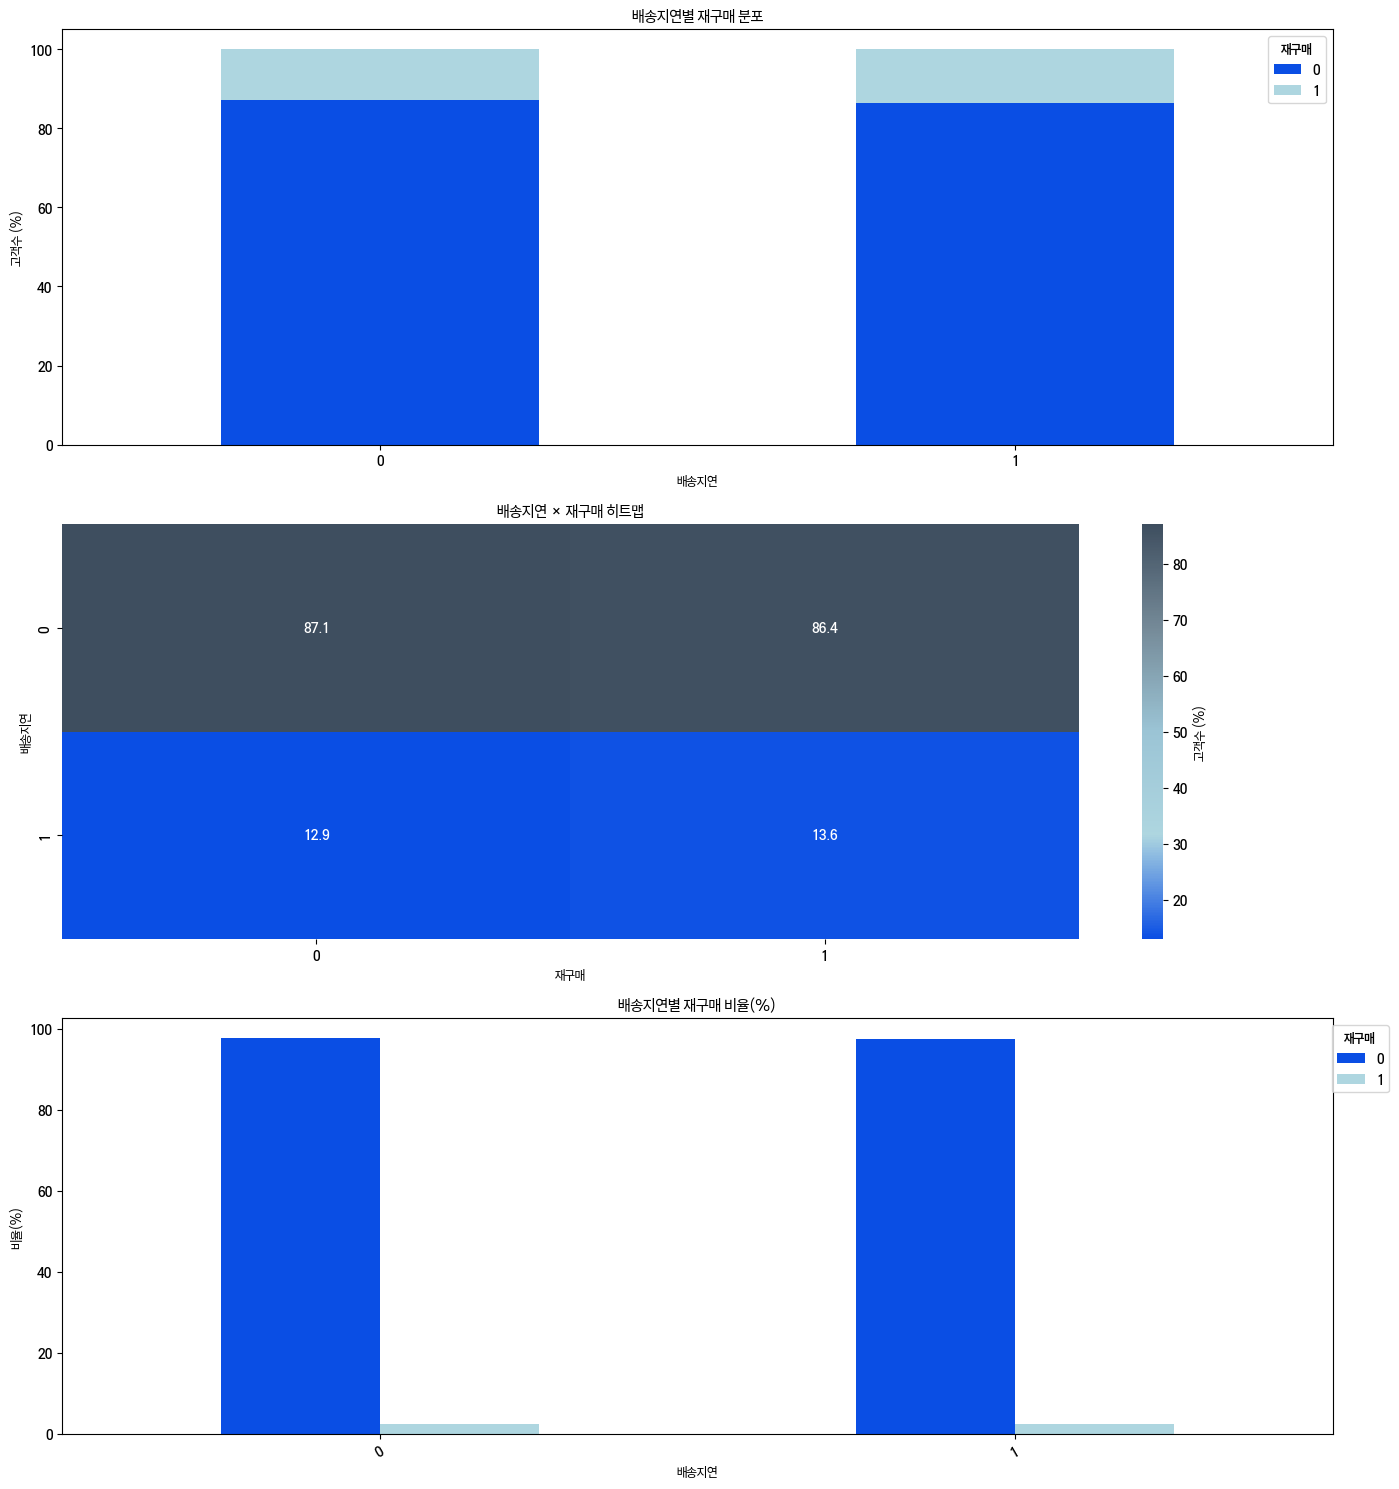

In [22]:
# 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)

colors = ["#0A4EE4", "#AED6E0", "#9BC4D5", "#758A98", "#3E4E5F"]




# TODO: 1. 데이터 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# 누적 막대그래프
plot_stacked_bar(ct_raw, axes[0], var1, var2, label, colors=colors, normalize='column')

# 히트맵
plot_heatmap(ct_raw, axes[1], var1, var2, label, cmap=generate_colormap(colors), normalize='column')


# 비율 막대그래프
plot_prop_bar(ct_raw, axes[2], var1, var2, colors, xrotation=30)


plt.tight_layout()
plt.show()

[이진 변수 분석]
카이제곱 검정: χ²=0.03, p=0.8707
지연 시 재구매율: 2.42%
비지연 시 재구매율: 2.29%

[연속 변수 분석]
상관계수: r=-0.0102, p=0.3433
로지스틱 계수: -0.005538
→ 지연 1일 증가 시 재구매 로그오즈 -0.0055 변화
2차 모델 계수: [-5.55394058e-03 -1.62333144e-05]

✅ 시각화 저장 완료


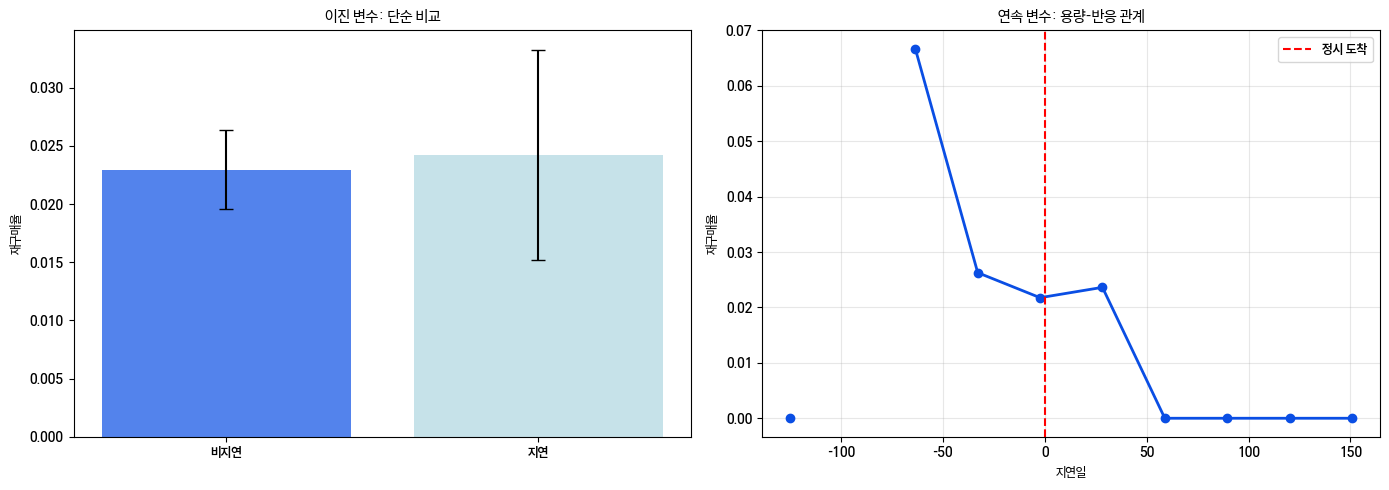

In [29]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression, LinearRegression
import matplotlib.pyplot as plt

df = first_orders.copy()

# === 방법 1: 이진 변수 접근 ===
df['배송지연'] = (df['지연일'] > 0).astype(int)

# 카이제곱 검정
ct = pd.crosstab(df['배송지연'], df['재구매'])
chi2, p_chi = stats.chi2_contingency(ct)[:2]

print("[이진 변수 분석]")
print(f"카이제곱 검정: χ²={chi2:.2f}, p={p_chi:.4f}")
print(f"지연 시 재구매율: {df[df['배송지연']==1]['재구매'].mean()*100:.2f}%")
print(f"비지연 시 재구매율: {df[df['배송지연']==0]['재구매'].mean()*100:.2f}%")

# === 방법 2: 연속 변수 접근 ===
# (2-1) 상관분석
corr, p_corr = stats.pearsonr(df['지연일'], df['재구매'])

# (2-2) 로지스틱 회귀 (연속 예측변수)
X = df[['지연일']]
y = df['재구매']
model = LogisticRegression()
model.fit(X, y)
coef = model.coef_[0][0]

print(f"\n[연속 변수 분석]")
print(f"상관계수: r={corr:.4f}, p={p_corr:.4f}")
print(f"로지스틱 계수: {coef:.6f}")
print(f"→ 지연 1일 증가 시 재구매 로그오즈 {coef:.4f} 변화")

# (2-3) 비선형 관계 탐색
df['지연일_제곱'] = df['지연일'] ** 2
X2 = df[['지연일', '지연일_제곱']]
model2 = LogisticRegression(max_iter=1000)
model2.fit(X2, y)

print(f"2차 모델 계수: {model2.coef_[0]}")
if abs(model2.coef_[0][1]) > 0.0001:
    print("⚠️ U자형/역U자형 패턴 가능성 있음")

# === 시각화: 연속변수의 장점 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 이진 변수
ax1 = axes[0]
binary_summary = df.groupby('배송지연', observed=True)['재구매'].agg(['mean', 'sem'])
ax1.bar([0, 1], binary_summary['mean'], yerr=binary_summary['sem']*1.96,
        capsize=5, color=colors[:2], alpha=0.7)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['비지연', '지연'])
ax1.set_ylabel('재구매율')
ax1.set_title('이진 변수: 단순 비교')

# 우: 연속 변수 (구간별 추세)
ax2 = axes[1]
bins = pd.cut(df['지연일'], bins=10)
trend = df.groupby(bins, observed=False)['재구매'].mean()
bin_centers = [interval.mid for interval in trend.index]
ax2.plot(bin_centers, trend.values, marker='o', linewidth=2, color=colors[0])
ax2.axvline(0, color='red', linestyle='--', label='정시 도착')
ax2.set_xlabel('지연일')
ax2.set_ylabel('재구매율')
ax2.set_title('연속 변수: 용량-반응 관계')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('binary_vs_continuous.png', dpi=150)
print("\n✅ 시각화 저장 완료")

[배송지연 분포]
배송지연
0    87.07
1    12.93
Name: proportion, dtype: float64

[재구매 분포]
재구매
0    97.69
1     2.31
Name: proportion, dtype: float64

[교차표 - 전체 대비 %]
재구매       0     1
배송지연             
0     85.07  2.00
1     12.62  0.31

[카이제곱 검정 결과]
χ² = 0.0265, p = 0.870719, df = 1
Cramér's V = 0.0018 (0.1↓:약함, 0.3↓:중간, 0.5↑:강함)
❌ 두 변수는 독립적 (관계 없음)

[로지스틱 회귀 결과 - 가중치 적용]
오즈비 (OR) = 1.0569
→ 배송지연=1일 때 재구매 확률이 5.7% 증가

✅ 시각화 저장: binary_relationship_analysis.png


'""\n\n## ③ 시각화 해석 포인트\n\n| 시각화 | 해석 방법 | 주의사항 |\n|--------|----------|---------|\n| **히트맵** | 행별(조건부) 비율 차이 확인 | 불균형시 절대 빈도도 함께 표시 |\n| **막대+CI** | 신뢰구간 겹치면 차이 없음 | 불균형시 CI 폭이 넓어짐 |\n| **모자이크** | 면적 = 빈도, 색상 = 비율 | 극단 불균형시 판독 어려움 |\n\n**💡 불균형 데이터 보정 전략**\n1. **분석 단계**: 가중치 적용 (로지스틱 회귀 `sample_weight`)\n2. **시각화**: 절대 빈도와 비율 동시 표시\n3. **해석**: 효과크기(Cramér\'s V, 오즈비) 우선 확인\n\n---\n\n## ④ 최종 분석 체크리스트\n```\n✅ 1. 불균형 정도 확인 (value_counts)\n✅ 2. 카이제곱 검정 → p-value + Cramér\'s V \n✅ 3. 로지스틱 회귀 → 오즈비 (가중치 적용)\n✅ 4. 시각화 3종 (히트맵/막대/모자이크)\n✅ 5. 효과크기 < 0.1이면 실무적 의미 재검토\n\n'

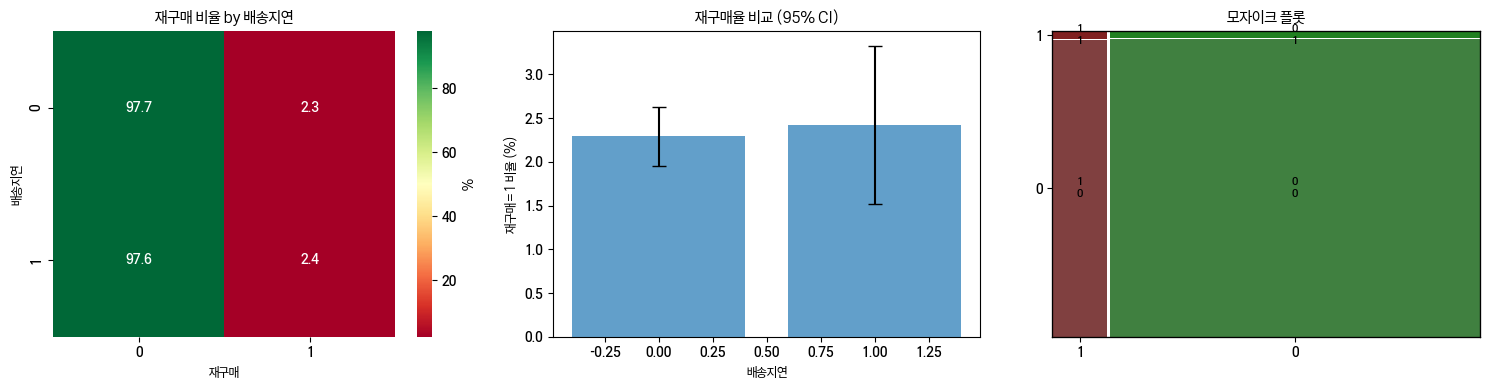

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

# === 1단계: 불균형 탐색 ===
def check_imbalance(df, var1, var2):
    """두 이진변수의 분포 확인"""
    print("=" * 60)
    print(f"[{var1} 분포]")
    print(df[var1].value_counts(normalize=True).mul(100).round(2))
    print(f"\n[{var2} 분포]")
    print(df[var2].value_counts(normalize=True).mul(100).round(2))
    
    # 교차표
    ct = pd.crosstab(df[var1], df[var2], normalize='all').mul(100).round(2)
    print(f"\n[교차표 - 전체 대비 %]")
    print(ct)
    return ct

# 예시 데이터
data = first_orders.copy()

ct = check_imbalance(data, '배송지연', '재구매')


# === 2단계: 카이제곱 검정 + 효과크기 ===
def chi_square_test(df, var1, var2):
    """카이제곱 검정 + Cramér's V"""
    ct_raw = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, expected = chi2_contingency(ct_raw)
    
    # Cramér's V (효과크기)
    n = ct_raw.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct_raw.shape) - 1)))
    
    print("\n" + "=" * 60)
    print("[카이제곱 검정 결과]")
    print(f"χ² = {chi2:.4f}, p = {p:.6f}, df = {dof}")
    print(f"Cramér's V = {cramers_v:.4f} ", end="")
    print("(0.1↓:약함, 0.3↓:중간, 0.5↑:강함)")
    
    # 해석
    if p < 0.05:
        print("✅ 두 변수는 통계적으로 유의한 관계 있음")
        if cramers_v < 0.1:
            print("⚠️ 단, 효과크기가 매우 작음 (실무적 의미 제한적)")
    else:
        print("❌ 두 변수는 독립적 (관계 없음)")
    
    return chi2, p, cramers_v

chi_square_test(data, '배송지연', '재구매')


# === 3단계: 로지스틱 회귀 (불균형 보정) ===
def logistic_analysis(df, predictor, outcome):
    """클래스 가중치 적용 로지스틱 회귀"""
    X = df[[predictor]].values
    y = df[outcome].values
    
    # 가중치 계산
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    sample_weights = np.array([weights[int(i)] for i in y])
    
    # 모델 학습
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y, sample_weight=sample_weights)
    
    # 오즈비 계산
    coef = model.coef_[0][0]
    odds_ratio = np.exp(coef)
    
    print("\n" + "=" * 60)
    print("[로지스틱 회귀 결과 - 가중치 적용]")
    print(f"오즈비 (OR) = {odds_ratio:.4f}")
    
    if odds_ratio > 1:
        print(f"→ {predictor}=1일 때 {outcome} 확률이 {(odds_ratio-1)*100:.1f}% 증가")
    else:
        print(f"→ {predictor}=1일 때 {outcome} 확률이 {(1-odds_ratio)*100:.1f}% 감소")
    
    return odds_ratio

logistic_analysis(data, '배송지연', '재구매')


# === 4단계: 시각화 ===
def visualize_relationship(df, var1, var2):
    """3종 시각화: 비율 히트맵 + 막대그래프 + 모자이크"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # (1) 히트맵 - 조건부 확률
    ct_norm = pd.crosstab(df[var1], df[var2], normalize='index').mul(100)
    sns.heatmap(ct_norm, annot=True, fmt='.1f', cmap='RdYlGn', 
                ax=axes[0], cbar_kws={'label': '%'})
    axes[0].set_title(f'{var2} 비율 by {var1}')
    
    # (2) 막대그래프 + 95% CI
    summary = df.groupby(var1)[var2].agg(['mean', 'sem']).mul(100)
    summary['ci'] = summary['sem'] * 1.96
    
    axes[1].bar(summary.index, summary['mean'], 
                yerr=summary['ci'], capsize=5, alpha=0.7)
    axes[1].set_ylabel(f'{var2}=1 비율 (%)')
    axes[1].set_xlabel(var1)
    axes[1].set_title('재구매율 비교 (95% CI)')
    
    # (3) 모자이크 플롯 (비율 시각화)
    from statsmodels.graphics.mosaicplot import mosaic
    mosaic(df, [var1, var2], ax=axes[2], title='모자이크 플롯')
    
    plt.tight_layout()
    plt.savefig('binary_relationship_analysis.png', dpi=150)
    print("\n✅ 시각화 저장: binary_relationship_analysis.png")

visualize_relationship(data, '배송지연', '재구매')

"""""

## ③ 시각화 해석 포인트

| 시각화 | 해석 방법 | 주의사항 |
|--------|----------|---------|
| **히트맵** | 행별(조건부) 비율 차이 확인 | 불균형시 절대 빈도도 함께 표시 |
| **막대+CI** | 신뢰구간 겹치면 차이 없음 | 불균형시 CI 폭이 넓어짐 |
| **모자이크** | 면적 = 빈도, 색상 = 비율 | 극단 불균형시 판독 어려움 |

**💡 불균형 데이터 보정 전략**
1. **분석 단계**: 가중치 적용 (로지스틱 회귀 `sample_weight`)
2. **시각화**: 절대 빈도와 비율 동시 표시
3. **해석**: 효과크기(Cramér's V, 오즈비) 우선 확인

---

## ④ 최종 분석 체크리스트
```
✅ 1. 불균형 정도 확인 (value_counts)
✅ 2. 카이제곱 검정 → p-value + Cramér's V 
✅ 3. 로지스틱 회귀 → 오즈비 (가중치 적용)
✅ 4. 시각화 3종 (히트맵/막대/모자이크)
✅ 5. 효과크기 < 0.1이면 실무적 의미 재검토

"""

In [25]:

# 독립표본 t-검정
t_stat, p_value_t = stats.ttest_ind(delayed_group, non_delayed_group)

# Cohen's d (효과크기) 계산
def cohens_d(group1, group2):
    """Cohen's d 효과크기 계산"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0
    
    return (group1.mean() - group2.mean()) / pooled_std

effect_size = cohens_d(delayed_group, non_delayed_group)

print("\n[독립표본 t-검정: 지연 vs 비지연]")
print(f"✓ 지연 그룹:")
print(f"   - 재구매율: {delayed_group.mean()*100:.2f}%")
print(f"   - 샘플 수: {len(delayed_group):,}명")
ci_delayed = calculate_ci(delayed_group)
print(f"   - 95% CI: [{ci_delayed[0]*100:.2f}%, {ci_delayed[1]*100:.2f}%]")

print(f"\n✓ 비지연 그룹:")
print(f"   - 재구매율: {non_delayed_group.mean()*100:.2f}%")
print(f"   - 샘플 수: {len(non_delayed_group):,}명")
ci_non_delayed = calculate_ci(non_delayed_group)
print(f"   - 95% CI: [{ci_non_delayed[0]*100:.2f}%, {ci_non_delayed[1]*100:.2f}%]")

print(f"\n✓ 통계량:")
print(f"   - t-통계량: {t_stat:.4f}")
print(f"   - p-value: {p_value_t:.6f}")
print(f"   - Cohen's d (효과크기): {effect_size:.4f}")

# Cohen's d 해석
def interpret_cohens_d(d):
    d_abs = abs(d)
    if d_abs < 0.2:
        return "매우 작음 (무시 가능)"
    elif d_abs < 0.5:
        return "작음"
    elif d_abs < 0.8:
        return "중간"
    else:
        return "큼"

print(f"   - 효과크기 해석: {interpret_cohens_d(effect_size)}")

if p_value_t < 0.05:
    print("\n✅ 결과: 통계적으로 유의미한 차이 존재 (p < 0.05)")
    if abs(effect_size) < 0.2:
        print("   ⚠️  단, 효과크기가 매우 작아 실용적 의미는 제한적일 수 있음")
else:
    print("\n❌ 결과: 통계적으로 유의미한 차이 없음 (p >= 0.05)")

# 6-2. 카이제곱 검정 및 Cramér's V
contingency_table = pd.crosstab(first_orders['지연일'], first_orders['재구매'])
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

# Cramér's V (효과크기)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / n)

print("\n[카이제곱 검정]")
print(f"✓ 교차표:")
print(contingency_table)
print(f"\n✓ 카이제곱 통계량: {chi2:.4f}")
print(f"✓ p-value: {p_value_chi:.6f}")
print(f"✓ 자유도: {dof}")
print(f"✓ Cramér's V (효과크기): {cramers_v:.4f}")

def interpret_cramers_v(v, dof):
    """Cramér's V 해석 (자유도 1 기준)"""
    if v < 0.1:
        return "매우 작음"
    elif v < 0.3:
        return "작음"
    elif v < 0.5:
        return "중간"
    else:
        return "큼"

print(f"✓ 효과크기 해석: {interpret_cramers_v(cramers_v, dof)}")

if p_value_chi < 0.05:
    print("\n✅ 결과: 배송 지연과 재구매율 간 독립성 기각 (연관성 존재)")
    if cramers_v < 0.1:
        print("   ⚠️  단, 효과크기가 매우 작아 실용적 연관성은 약함")
else:
    print("\n❌ 결과: 배송 지연과 재구매율 간 연관성 없음")

# 6-3. Mann-Whitney U 검정 (비모수 검정 - 불균형 데이터에 강건)
u_stat, p_value_u = stats.mannwhitneyu(delayed_group, non_delayed_group, alternative='two-sided')

print("\n[Mann-Whitney U 검정 (비모수 검정)]")
print(f"✓ U-통계량: {u_stat:.4f}")
print(f"✓ p-value: {p_value_u:.6f}")

if p_value_u < 0.05:
    print("✅ 결과: 통계적으로 유의미한 차이 존재 (비모수 검정)")
else:
    print("❌ 결과: 통계적으로 유의미한 차이 없음 (비모수 검정)")

# =============================================================================
# 7. 클래스 불균형 고려 로지스틱 회귀 분석
# =============================================================================
print("\n" + "=" * 80)
print("📐 [7단계] 로지스틱 회귀 분석 (클래스 가중치 적용)")
print("=" * 80)

from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc

# 결측치 제거
regression_data = first_orders[['지연일', '재구매']].dropna()

# 표준화
scaler = StandardScaler()
X = scaler.fit_transform(regression_data[['지연일']])
y = regression_data['재구매']

# 7-1. 일반 로지스틱 회귀
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X, y)

# 7-2. 클래스 가중치 적용 로지스틱 회귀
log_reg_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg_balanced.fit(X, y)

# 예측
y_pred_prob = log_reg.predict_proba(X)[:, 1]
y_pred_prob_balanced = log_reg_balanced.predict_proba(X)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y, y_pred_prob)
roc_auc_balanced = roc_auc_score(y, y_pred_prob_balanced)

# Precision-Recall AUC (불균형 데이터에 더 적합)
precision, recall, _ = precision_recall_curve(y, y_pred_prob)
pr_auc = auc(recall, precision)

precision_balanced, recall_balanced, _ = precision_recall_curve(y, y_pred_prob_balanced)
pr_auc_balanced = auc(recall_balanced, precision_balanced)

print("\n[모델 1: 일반 로지스틱 회귀]")
coef = log_reg.coef_[0][0]
intercept = log_reg.intercept_[0]
print(f"✓ 계수 (표준화): {coef:.4f}")
print(f"✓ 절편: {intercept:.4f}")

original_coef = coef / scaler.scale_[0]
odds_ratio = np.exp(original_coef)
print(f"\n✓ 원래 스케일 계수: {original_coef:.6f}")
print(f"✓ 오즈비: {odds_ratio:.4f}")
print(f"✓ 해석: 배송 지연 1일 증가 시 재구매 오즈가 {(1-odds_ratio)*100:.2f}% 감소")

print(f"\n✓ 성능 지표:")
print(f"   - ROC-AUC: {roc_auc:.4f}")
print(f"   - PR-AUC: {pr_auc:.4f} (불균형 데이터에 더 적합한 지표)")

print("\n[모델 2: 클래스 가중치 적용 로지스틱 회귀]")
coef_balanced = log_reg_balanced.coef_[0][0]
intercept_balanced = log_reg_balanced.intercept_[0]
print(f"✓ 계수 (표준화): {coef_balanced:.4f}")
print(f"✓ 절편: {intercept_balanced:.4f}")

original_coef_balanced = coef_balanced / scaler.scale_[0]
odds_ratio_balanced = np.exp(original_coef_balanced)
print(f"\n✓ 원래 스케일 계수: {original_coef_balanced:.6f}")
print(f"✓ 오즈비: {odds_ratio_balanced:.4f}")
print(f"✓ 해석: 배송 지연 1일 증가 시 재구매 오즈가 {(1-odds_ratio_balanced)*100:.2f}% 감소")

print(f"\n✓ 성능 지표:")
print(f"   - ROC-AUC: {roc_auc_balanced:.4f}")
print(f"   - PR-AUC: {pr_auc_balanced:.4f}")

print("\n💡 권장 모델: ", end="")
if pr_auc_balanced > pr_auc:
    print("클래스 가중치 적용 모델 (불균형 데이터에 더 적합)")
else:
    print("일반 모델")



[독립표본 t-검정: 지연 vs 비지연]
✓ 지연 그룹:
   - 재구매율: 2.42%
   - 샘플 수: 1,114명
   - 95% CI: [1.67%, 3.50%]

✓ 비지연 그룹:
   - 재구매율: 2.29%
   - 샘플 수: 7,499명
   - 95% CI: [1.98%, 2.66%]

✓ 통계량:
   - t-통계량: 0.2696
   - p-value: 0.787491
   - Cohen's d (효과크기): 0.0087
   - 효과크기 해석: 매우 작음 (무시 가능)

❌ 결과: 통계적으로 유의미한 차이 없음 (p >= 0.05)

[카이제곱 검정]
✓ 교차표:
재구매   0  1
지연일       
-140  1  0
-77   1  0
-69   1  0
-65   1  0
-64   0  1
...  .. ..
 138  1  0
 155  1  0
 159  1  0
 161  1  0
 166  1  0

[130 rows x 2 columns]

✓ 카이제곱 통계량: 136.9000
✓ p-value: 0.300331
✓ 자유도: 129
✓ Cramér's V (효과크기): 0.1261
✓ 효과크기 해석: 작음

❌ 결과: 배송 지연과 재구매율 간 연관성 없음

[Mann-Whitney U 검정 (비모수 검정)]
✓ U-통계량: 4182375.5000
✓ p-value: 0.787492
❌ 결과: 통계적으로 유의미한 차이 없음 (비모수 검정)

📐 [7단계] 로지스틱 회귀 분석 (클래스 가중치 적용)

[모델 1: 일반 로지스틱 회귀]
✓ 계수 (표준화): -0.0734
✓ 절편: -3.7467

✓ 원래 스케일 계수: -0.005450
✓ 오즈비: 0.9946
✓ 해석: 배송 지연 1일 증가 시 재구매 오즈가 0.54% 감소

✓ 성능 지표:
   - ROC-AUC: 0.5246
   - PR-AUC: 0.0247 (불균형 데이터에 더 적합한 지표)

[모델 2: 클래스 가중치 적용 로지스틱 회귀]
✓ 계수 (표준화): -

In [26]:

# =============================================================================
# 8. 시뮬레이션: 배송 지연 개선 시 재구매율 증가 예측
# =============================================================================
print("\n" + "=" * 80)
print("🎯 [8단계] 배송 지연 개선 시 재구매 증가 시뮬레이션")
print("=" * 80)

# 현재 상태
current_delayed_rate = first_orders['지연일'].mean()
current_repurchase_rate = first_orders['재구매'].mean()

print(f"\n[현재 상태]")
print(f"✓ 배송 지연 비율: {current_delayed_rate*100:.2f}%")
print(f"✓ 전체 재구매율: {current_repurchase_rate*100:.2f}%")
print(f"✓ 연간 신규 고객: 91,255명 (데이터 기준)")

# 시나리오별 시뮬레이션
scenarios = [
    {"name": "시나리오 1: 지연율 50% 감소", "reduction": 0.5},
    {"name": "시나리오 2: 지연율 70% 감소", "reduction": 0.7},
    {"name": "시나리오 3: 지연율 90% 감소 (거의 제로)", "reduction": 0.9}
]

print(f"\n[시뮬레이션 결과]")
for scenario in scenarios:
    # 지연율 감소
    new_delayed_rate = current_delayed_rate * (1 - scenario['reduction'])
    
    # 지연 고객이 비지연 고객으로 전환
    improved_customers = (current_delayed_rate - new_delayed_rate) * len(first_orders)
    
    # 재구매율 개선 (지연→비지연 전환 효과)
    repurchase_gain = improved_customers * (non_delayed_group.mean() - delayed_group.mean())
    
    new_repurchase_rate = (first_orders['재구매'].sum() + repurchase_gain) / len(first_orders)
    
    print(f"\n{scenario['name']}")
    print(f"  • 새로운 지연율: {new_delayed_rate*100:.2f}%")
    print(f"  • 새로운 재구매율: {new_repurchase_rate*100:.2f}%")
    print(f"  • 재구매율 증가: {(new_repurchase_rate - current_repurchase_rate)*100:.2f}%p")
    print(f"  • 추가 재구매 고객: 약 {int(repurchase_gain):,}명/년")
    
    # 비즈니스 임팩트
    if repurchase_gain > 0:
        avg_order_value = 100  # 가정: 평균 주문액 100 BRL
        additional_revenue = repurchase_gain * avg_order_value
        print(f"  • 예상 추가 매출: 약 {additional_revenue:,.0f} BRL/년")

print("\n" + "=" * 80)


🎯 [8단계] 배송 지연 개선 시 재구매 증가 시뮬레이션

[현재 상태]
✓ 배송 지연 비율: -1116.06%
✓ 전체 재구매율: 2.31%
✓ 연간 신규 고객: 91,255명 (데이터 기준)

[시뮬레이션 결과]

시나리오 1: 지연율 50% 감소
  • 새로운 지연율: -558.03%
  • 새로운 재구매율: 3.04%
  • 재구매율 증가: 0.73%p
  • 추가 재구매 고객: 약 62명/년
  • 예상 추가 매출: 약 6,251 BRL/년

시나리오 2: 지연율 70% 감소
  • 새로운 지연율: -334.82%
  • 새로운 재구매율: 3.33%
  • 재구매율 증가: 1.02%p
  • 추가 재구매 고객: 약 87명/년
  • 예상 추가 매출: 약 8,751 BRL/년

시나리오 3: 지연율 90% 감소 (거의 제로)
  • 새로운 지연율: -111.61%
  • 새로운 재구매율: 3.62%
  • 재구매율 증가: 1.31%p
  • 추가 재구매 고객: 약 112명/년
  • 예상 추가 매출: 약 11,252 BRL/년

